In [1]:
import functions as fn
from mastu import HSV
import numpy as np
import sys

In [2]:
plot = True

In [3]:
### load the dictionary
dictFile = '/home/sthoma/tokamak_inversion_routines/Dictionaries/inputDict50499.txt'
inputDict = fn.loadDict(dictFile)

### unzip the dictionary
shotn = inputDict['shotn']
Rzfile = inputDict['Rzfile']
maskFile = inputDict['maskFile']

### the inputs to select which bits of video, and averaging
I0 = inputDict['I0']
I1 = inputDict['I1']
J0 = inputDict['J0']
J1 = inputDict['J1']
tend = inputDict['tend']
raverage = inputDict['raverage']
taverage = inputDict['taverage']
# T0 = inputDict['T0']
# T1 = inputDict['T1']
T0 = 500
T1 = 510

### for converting to photons and account for vignetting
photons = bool(inputDict['photons'])
exposureMult = inputDict['exposureMult']
vignette = bool(inputDict['vignette'])

### variables for the inversion, should be approximately constant
saveFile = inputDict['saveFile']
rEnd = inputDict['rEnd']
nrMult = inputDict['nrMult']
sysErr = inputDict['sysErr']
photon = bool(inputDict['photon'])
biasedEdges = bool(inputDict['biasedEdges'])
nFisher = inputDict['nFisher']
regGuess = inputDict['regGuess']
regMin = inputDict['regMin']

### use pedestal fitting or raw Thomson
kindThomson = inputDict['kindThomson']
### R value pedestal fitting works up to
Rprofile0 = inputDict['Rprofile0']

### kind of interpolation to use, don't need to change
line = inputDict['line']
kindExcite = inputDict['kindExcite']
kindRecomb = inputDict['kindRecomb']
kindIonise = inputDict['kindIonise']

### using a constant percentage for profile error
percent = inputDict['percent']

### temperature to assume for neutral density from fig
figTemp = inputDict['figTemp']

In [4]:
nFisher, regGuess, regMin

(4, 0.7, 0.4)

In [5]:
### load the Rz coordinates
R0, z0 = HSV.getRz(Rzfile, I0, I1, J0, J1)

### prepping R, adding extra, and flipping
R, goodChans, flipBool = fn.prepR(R0, rEnd)
### grid to interpolate onto
nGrid = int(len(R0) * nrMult)
Rgrid, RgridB = fn.makeGrid(R, nGrid)
### making dL
dL = fn.makeDL(Rgrid, R)

In [6]:
### quicker than loading the whole dataset
trange = HSV.makeTimeRange(shotn, T0, T1)
### load the data from UDA
rawData, time = HSV.get(shotn, trange=trange)

### 
dSlice = (slice(I0,I1), slice(J0,J1), slice(0,len(time)))
data, err = HSV.prepData(
    shotn, rawData, dSlice, goodChans, flipBool, 
    rEnd, tend, sysErr=sysErr, photon=photon
)
### average in space and time if wanted
if raverage:
    data = HSV.makeRadialAverage(data, raverage, rEnd)
    err = HSV.makeRadialAverage(err, raverage, rEnd)
if taverage:
    data = HSV.makeTimeAverage(data, taverage)
    err = HSV.makeTimeAverage(err, taverage)

# ### chop down to selected time range
# tSlice = slice(T0, T1)
# data = data[tSlice,:]
# err = err[tSlice,:]
# time = time[tSlice]

### convert to ph m^-2 sr^-1
if photons:
    data, err = HSV.applyCalibration(data, err, inputDict)

### convert to ph m^-2 sr^-1 s^-1
data, err = HSV.applyExposure(data, err, shotn, mult=exposureMult)

### apply vignette function
if vignette:
    data, err = HSV.applyVignette(
        data, err, inputDict, shotn, dSlice[:-1], flipBool, rEnd
    )

### sizes of data
nT, nR = data.shape
### scale so not working with large numbers
scale = fn.makeScale(data)

In [7]:
2.**np.arange(-2.,5.,1.)

array([ 0.25,  0.5 ,  1.  ,  2.  ,  4.  ,  8.  , 16.  ])

In [8]:
########################################
### Scaling my regularisation matrix ###
########################################
Dmult = 1.

In [9]:
# def regulMatrix(nGrid, biasedEdges=True):
#     ### regularization band matrix
#     bias = .1 if biasedEdges else 1e-5
#     ### (3 x R_grid-1), all 1s
#     D = np.ones((3, nGrid-1))
#     ### make row 1 all negative 2s
#     D[1, :] *= -2
#     ### last in middle row is bias value
# #     D[1, -1] = bias
#     ### middle row, first element and second last element are negative 1s
# #     D[1, [0, nGrid-3]] = -1
#     ### last row, elements -2 and -3 are set to zero
# #     D[2, [-2, -3]] = 0
#     return D

def regulMatrix(nGrid, biasedEdges=True):
    ### regularization band matrix
    bias = .1 if biasedEdges else 1e-5
    ### (3 x R_grid-1), all 1s
    D = np.ones((5, nGrid-1))
    ### make row 1 all negative 2s
    D[0, :] *= (-1. / 12.)
    D[1, :] *= (4. / 3.)
    D[2, :] *= (-5. / 2.)
    D[3, :] *= (4. / 3.)
    D[4, :] *= (-1. / 12.)
    ### last in middle row is bias value
#     D[1, -1] = bias
    ### middle row, first element and second last element are negative 1s
#     D[1, [0, nGrid-3]] = -1
    ### last row, elements -2 and -3 are set to zero
#     D[2, [-2, -3]] = 0
    return D

In [10]:
mask = np.ones(data.shape[1]).astype(bool)
# D = fn.regulMatrix(nGrid, biasedEdges=biasedEdges) * Dmult
D = regulMatrix(nGrid, biasedEdges=biasedEdges) * Dmult
indLos = slice(0, nR)
indSpace = slice(0, nGrid-1)
Q = np.linspace(0., 1., np.count_nonzero(mask))

In [11]:
D

array([[-0.08333333, -0.08333333, -0.08333333, ..., -0.08333333,
        -0.08333333, -0.08333333],
       [ 1.33333333,  1.33333333,  1.33333333, ...,  1.33333333,
         1.33333333,  1.33333333],
       [-2.5       , -2.5       , -2.5       , ..., -2.5       ,
        -2.5       , -2.5       ],
       [ 1.33333333,  1.33333333,  1.33333333, ...,  1.33333333,
         1.33333333,  1.33333333],
       [-0.08333333, -0.08333333, -0.08333333, ..., -0.08333333,
        -0.08333333, -0.08333333]])

In [12]:
data.shape, err.shape

((10, 185), (10, 185))

In [13]:
dL.shape

(185, 459)

In [14]:
import matplotlib.pyplot as plt
%matplotlib widget

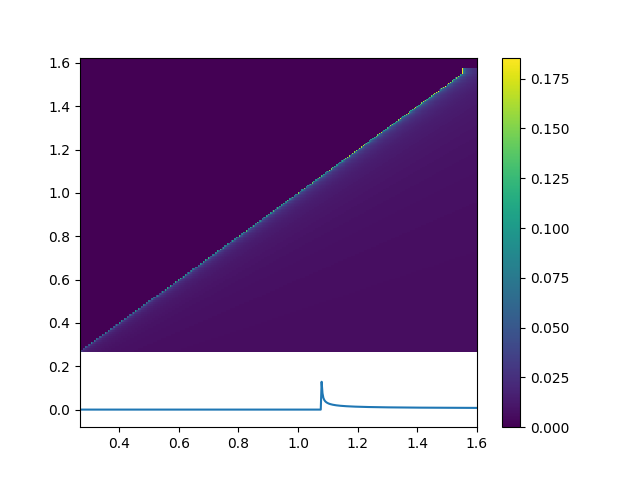

In [15]:
plt.figure()
plt.pcolormesh(RgridB, R, dL)
plt.colorbar()
plt.plot(RgridB, dL[100])

In [16]:
scale

9.390335033426588e+18

In [17]:
nGrid

460

In [18]:
Q

array([0.        , 0.00543478, 0.01086957, 0.01630435, 0.02173913,
       0.02717391, 0.0326087 , 0.03804348, 0.04347826, 0.04891304,
       0.05434783, 0.05978261, 0.06521739, 0.07065217, 0.07608696,
       0.08152174, 0.08695652, 0.0923913 , 0.09782609, 0.10326087,
       0.10869565, 0.11413043, 0.11956522, 0.125     , 0.13043478,
       0.13586957, 0.14130435, 0.14673913, 0.15217391, 0.1576087 ,
       0.16304348, 0.16847826, 0.17391304, 0.17934783, 0.18478261,
       0.19021739, 0.19565217, 0.20108696, 0.20652174, 0.21195652,
       0.2173913 , 0.22282609, 0.22826087, 0.23369565, 0.23913043,
       0.24456522, 0.25      , 0.25543478, 0.26086957, 0.26630435,
       0.27173913, 0.27717391, 0.2826087 , 0.28804348, 0.29347826,
       0.29891304, 0.30434783, 0.30978261, 0.31521739, 0.32065217,
       0.32608696, 0.33152174, 0.33695652, 0.3423913 , 0.34782609,
       0.35326087, 0.35869565, 0.36413043, 0.36956522, 0.375     ,
       0.38043478, 0.38586957, 0.39130435, 0.39673913, 0.40217

In [19]:
D.shape

(5, 459)

In [20]:
D

array([[-0.08333333, -0.08333333, -0.08333333, ..., -0.08333333,
        -0.08333333, -0.08333333],
       [ 1.33333333,  1.33333333,  1.33333333, ...,  1.33333333,
         1.33333333,  1.33333333],
       [-2.5       , -2.5       , -2.5       , ..., -2.5       ,
        -2.5       , -2.5       ],
       [ 1.33333333,  1.33333333,  1.33333333, ...,  1.33333333,
         1.33333333,  1.33333333],
       [-0.08333333, -0.08333333, -0.08333333, ..., -0.08333333,
        -0.08333333, -0.08333333]])

In [21]:
D[:,:5]

array([[-0.08333333, -0.08333333, -0.08333333, -0.08333333, -0.08333333],
       [ 1.33333333,  1.33333333,  1.33333333,  1.33333333,  1.33333333],
       [-2.5       , -2.5       , -2.5       , -2.5       , -2.5       ],
       [ 1.33333333,  1.33333333,  1.33333333,  1.33333333,  1.33333333],
       [-0.08333333, -0.08333333, -0.08333333, -0.08333333, -0.08333333]])

In [22]:
D[:,-5:]

array([[-0.08333333, -0.08333333, -0.08333333, -0.08333333, -0.08333333],
       [ 1.33333333,  1.33333333,  1.33333333,  1.33333333,  1.33333333],
       [-2.5       , -2.5       , -2.5       , -2.5       , -2.5       ],
       [ 1.33333333,  1.33333333,  1.33333333,  1.33333333,  1.33333333],
       [-0.08333333, -0.08333333, -0.08333333, -0.08333333, -0.08333333]])

In [23]:
indLos

slice(0, 185, None)

In [24]:
indSpace

slice(0, 459, None)

In [25]:
nFisher, regGuess, regMin

(4, 0.7, 0.4)

In [26]:
tind = 0

errZinds = np.where(np.isclose(err[tind], 0.))
T = dL / err[tind,:,None] * scale
mean_d = data[tind] / err[tind]
### replace infs and NaNs
T[errZinds] = 0.
mean_d[errZinds] = 0.

In [27]:
W = np.ones(nGrid-1)
W

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1.

In [28]:
### normally iterates over nfisher here, hence the f=0, this is the first iteration
f = 0

### multiply tridiagonal regularisation operator 
### by a diagonal weight matrix W
WD = np.copy(D)
### seems redundent, as W is all ones
WD[0,1:] *= W[:-1]
WD[1] *= W
WD[2,:-1] *= W[1:]

### transpose the band matrix
DTW = np.copy(WD)
DTW[0,1:], DTW[2,:-1] = WD[2,:-1], WD[0,1:]

In [29]:
np.isclose(WD, D).all(), np.isclose(D, WD).all()

(True, True)

In [30]:
DTW

array([[-0.08333333, -2.5       , -2.5       , ..., -2.5       ,
        -2.5       , -2.5       ],
       [ 1.33333333,  1.33333333,  1.33333333, ...,  1.33333333,
         1.33333333,  1.33333333],
       [-0.08333333, -0.08333333, -0.08333333, ..., -0.08333333,
        -0.08333333, -2.5       ],
       [ 1.33333333,  1.33333333,  1.33333333, ...,  1.33333333,
         1.33333333,  1.33333333],
       [-0.08333333, -0.08333333, -0.08333333, ..., -0.08333333,
        -0.08333333, -0.08333333]])

In [31]:
print(D[:,:5])
print('')
print(DTW[:,:5])

[[-0.08333333 -0.08333333 -0.08333333 -0.08333333 -0.08333333]
 [ 1.33333333  1.33333333  1.33333333  1.33333333  1.33333333]
 [-2.5        -2.5        -2.5        -2.5        -2.5       ]
 [ 1.33333333  1.33333333  1.33333333  1.33333333  1.33333333]
 [-0.08333333 -0.08333333 -0.08333333 -0.08333333 -0.08333333]]

[[-0.08333333 -2.5        -2.5        -2.5        -2.5       ]
 [ 1.33333333  1.33333333  1.33333333  1.33333333  1.33333333]
 [-0.08333333 -0.08333333 -0.08333333 -0.08333333 -0.08333333]
 [ 1.33333333  1.33333333  1.33333333  1.33333333  1.33333333]
 [-0.08333333 -0.08333333 -0.08333333 -0.08333333 -0.08333333]]


In [32]:
print(D[:,-5:])
print('')
print(DTW[:,-5:])

[[-0.08333333 -0.08333333 -0.08333333 -0.08333333 -0.08333333]
 [ 1.33333333  1.33333333  1.33333333  1.33333333  1.33333333]
 [-2.5        -2.5        -2.5        -2.5        -2.5       ]
 [ 1.33333333  1.33333333  1.33333333  1.33333333  1.33333333]
 [-0.08333333 -0.08333333 -0.08333333 -0.08333333 -0.08333333]]

[[-2.5        -2.5        -2.5        -2.5        -2.5       ]
 [ 1.33333333  1.33333333  1.33333333  1.33333333  1.33333333]
 [-0.08333333 -0.08333333 -0.08333333 -0.08333333 -2.5       ]
 [ 1.33333333  1.33333333  1.33333333  1.33333333  1.33333333]
 [-0.08333333 -0.08333333 -0.08333333 -0.08333333 -0.08333333]]


In [33]:
from scipy.interpolate import RegularGridInterpolator
from scipy.linalg import eigh, solve_banded

In [34]:
np.isclose(T[indLos,indSpace], T).all(), np.isclose(T, T[indLos,indSpace]).all()

(True, True)

In [35]:
# so if the nomenclature is the same in here as it is in the paper
# then the T is simlar to a geometry matrix

In [36]:
### (l, u), ab (shape is (3,459)), b (shape (459,185), after transpose), 
### the docstring example confuses me and doesn't seem
### to line up with my example

### solve Tikhonov regularization (optimised for speed)
H = solve_banded(
    (2, 2), DTW, T[indLos,indSpace].T, 
    overwrite_ab=True, check_finite=False
)

In [37]:
print(H.shape)
print(H)

(459, 185)
[[ 3.40446107e+60  2.56746738e+60  2.24823506e+60 ...  4.37216578e+61
   3.25023923e+62  0.00000000e+00]
 [-1.58874850e+60 -1.19815145e+60 -1.04917636e+60 ... -2.04034403e+61
  -1.51677831e+62  0.00000000e+00]
 [-9.60814568e+59 -7.24596351e+59 -6.34501893e+59 ... -1.23392234e+61
  -9.17289739e+61  0.00000000e+00]
 ...
 [ 2.71045523e-02  2.04409091e-02  1.78993989e-02 ...  3.59191045e-01
   2.67836702e+00  0.00000000e+00]
 [ 2.96512161e-03  2.23616986e-03  1.95815696e-03 ...  4.25093698e-02
   2.46517364e-01  0.00000000e+00]
 [-8.91959096e-03 -6.72668397e-03 -5.89029856e-03 ... -1.14565015e-01
  -8.77840000e-01 -0.00000000e+00]]


Some times you'll do a solve like this to avoid doing a direct inverse.<br>
So this is probably giving us some product with the inverse in (D^-1 T) to save us finding D^-1 directly. We use this in later steps

In [38]:
H.shape

(459, 185)

In [39]:
### so H is probably the same thing in here as it is in the paper too
#  probably gamma H is. So LL is the H later, LTL in the paper
### 
### also take a look at the Tikinhov wiki page and hte multivariate normal distribution wiki page

In [40]:
### fast method to calculate U, S, V = svd(H.T) of rectangular matrix
LL = np.dot(H.T, H)

### so it does the matrix multiplication of its transpose with itself

In [41]:
### L is a standard nomenclature for Cholesky Decomposition
### A = L LT
### this is to do with triangluar matrices and positive-definite matrices

In [42]:
LL

array([[1.76103457e+121, 1.32808063e+121, 1.16295048e+121, ...,
        2.26160174e+122, 1.68125983e+123, 0.00000000e+000],
       [1.32808063e+121, 1.00156931e+121, 8.77036740e+120, ...,
        1.70558235e+122, 1.26791868e+123, 0.00000000e+000],
       [1.16295048e+121, 8.77036740e+120, 7.67988235e+120, ...,
        1.49351460e+122, 1.11026891e+123, 0.00000000e+000],
       ...,
       [2.26160174e+122, 1.70558235e+122, 1.49351460e+122, ...,
        2.90445317e+123, 2.15915135e+124, 0.00000000e+000],
       [1.68125983e+123, 1.26791868e+123, 1.11026891e+123, ...,
        2.15915135e+124, 1.60509888e+125, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000]])

In [43]:
H.T.shape, H.shape

((185, 459), (459, 185))

In [44]:
LL.shape

(185, 185)

In [45]:
### also from scipy
S2, U = eigh(LL, overwrite_a=True, check_finite=False, lower=True)

### from scipy - 
### Solve a standrard or generalised eigenvalue problem for a 
### complex Hermitian or real symmetric matrix.

### S2 is w - selected eigenvalues, in ascending order, each 
###     repeated according to its multiplicity
### U is v - normalised eigenvector corresponding to the eigenvalue 
###     w[i] is the column v[:,i].

In [46]:
S2.shape, U.shape

((185,), (185, 185))

In [47]:
S2

array([-6.57702121e+109, -4.83518713e+109, -3.22248309e+109,
       -3.15556284e+109, -2.18988744e+109, -1.98855874e+109,
       -1.19532075e+109, -8.75044779e+108, -8.58445486e+108,
       -6.53086738e+108, -5.68139021e+108, -4.94947683e+108,
       -4.24035354e+108, -3.69138933e+108, -3.45862774e+108,
       -3.26123817e+108, -2.51156851e+108, -2.21242575e+108,
       -1.24520046e+108, -1.06525129e+108, -9.08577103e+107,
       -7.87837795e+107, -7.64006725e+107, -6.79302178e+107,
       -6.09524762e+107, -5.74015893e+107, -5.28209692e+107,
       -5.08507506e+107, -4.85155377e+107, -4.25921103e+107,
       -4.15914741e+107, -4.13993194e+107, -3.98963165e+107,
       -3.97917191e+107, -3.95577700e+107, -3.93348546e+107,
       -3.90732802e+107, -3.84304668e+107, -3.42904764e+107,
       -3.31423328e+107, -3.17848522e+107, -3.13826026e+107,
       -3.03441101e+107, -2.98658544e+107, -2.94936666e+107,
       -2.93198535e+107, -2.83322255e+107, -2.66493499e+107,
       -2.59005124e+107,

In [48]:
U

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        , -0.00747847],
       [ 0.70072287,  0.01490973,  0.0040061 , ...,  0.00836139,
         0.12760068, -0.00563987],
       [-0.1576149 , -0.01200391,  0.06555141, ..., -0.08115033,
         0.12443814, -0.00493863],
       ...,
       [-0.0391031 ,  0.01209476, -0.0540773 , ..., -0.17879388,
        -0.05652038, -0.09604198],
       [-0.00898194,  0.00744337, -0.01633875, ...,  0.00867573,
         0.63336951, -0.71396977],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]])

In [49]:
np.isclose(S2, np.maximum(S2, 1.))

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [50]:
### matrices with small eignevalues is basically making doing the 
### inverse problems difficult (not quite numerical issues, but it kind of leads to that)
### It can have really small values in reality, but it can lead to problems.
S2 = np.maximum(S2, 1.)
### check out what makes an invertible matrix in wiki

### a sanity check I can do is plot the eigenvalues (or max and min)
### 

In [51]:
mean_d[indLos].shape, U.shape, 

((185,), (185, 185))

In [52]:
###
mean_p = np.dot(mean_d[indLos], U)

### so I thnk this is matrix multiplication still

In [53]:
### the woodbury matrix identity


In [54]:
mean_d[indLos].shape

(185,)

In [55]:
mean_p

array([-5.44986872e+00, -8.45618897e+00,  1.44495403e+01, -5.94703115e+01,
        5.63980655e+00, -9.26564334e-03,  1.32715894e+01, -4.78286563e-01,
        1.06195143e+01, -6.82884982e+00, -1.92026568e+01,  1.30959306e+00,
       -1.26489808e+01,  8.31128480e+00,  6.20904677e+00, -1.12716160e+01,
       -3.37524434e+01,  1.61348270e+01, -1.84464975e+01, -1.67918071e+01,
       -1.41325475e+01, -8.41445507e+00, -8.76356941e+00,  5.88617731e+00,
        1.25638040e+00,  2.31088989e+01, -2.16686336e+01,  1.42982954e+01,
       -2.77097867e+01, -3.30028782e-02,  9.07847178e-01,  3.47966835e-02,
        4.29886844e+00,  4.17858826e+00,  4.31406466e+00, -3.30588964e+00,
       -1.09337540e+01,  3.56535141e+00,  7.89261724e+00, -6.29910788e+00,
       -2.25725303e+00,  1.08710075e+01,  9.14207871e-02, -1.01731972e+01,
       -1.58836429e+00,  1.17051624e+01, -5.60442306e+00, -4.68964895e+00,
       -9.58590068e+00,  3.63725275e-01, -6.12530050e+00,  1.28240000e+00,
        3.14039796e+00, -

In [56]:
### generalised cross validation
### 

In [57]:
### guess for regularisation - estimate quantile of log(S^2)
g0 = np.interp(regGuess, Q, np.log(S2))

In [58]:
g0

247.36995311688162

In [59]:
### if f == (nFisher - 1)
### but it doesn't, so not that branche
### else:

### filtering factor
w = 1. / (1. + np.exp(g0) / S2)
print(w)

[3.70334671e-108 3.70334671e-108 3.70334671e-108 3.70334671e-108
 3.70334671e-108 3.70334671e-108 3.70334671e-108 3.70334671e-108
 3.70334671e-108 3.70334671e-108 3.70334671e-108 3.70334671e-108
 3.70334671e-108 3.70334671e-108 3.70334671e-108 3.70334671e-108
 3.70334671e-108 3.70334671e-108 3.70334671e-108 3.70334671e-108
 3.70334671e-108 3.70334671e-108 3.70334671e-108 3.70334671e-108
 3.70334671e-108 3.70334671e-108 3.70334671e-108 3.70334671e-108
 3.70334671e-108 3.70334671e-108 3.70334671e-108 3.70334671e-108
 3.70334671e-108 3.70334671e-108 3.70334671e-108 3.70334671e-108
 3.70334671e-108 3.70334671e-108 3.70334671e-108 3.70334671e-108
 3.70334671e-108 3.70334671e-108 3.70334671e-108 3.70334671e-108
 3.70334671e-108 3.70334671e-108 3.70334671e-108 3.70334671e-108
 3.70334671e-108 3.70334671e-108 3.70334671e-108 3.70334671e-108
 3.70334671e-108 3.70334671e-108 3.70334671e-108 3.70334671e-108
 3.70334671e-108 3.70334671e-108 3.70334671e-108 3.70334671e-108
 3.70334671e-108 3.703346

In [60]:
### calcualte y without evaluatin v explicitely
Y = np.dot(H, np.dot(U / S2, w * mean_p))

### H is the output from solve_banded
### U is the second output from eigh
### S2 is the first output from eigh (but a minimum value of 1 imposed)
### w is a bunch of ones
### mean_p is the matrix multiplication of mean_d and U
###     mean_d is the data divided by the error

print(Y.shape)

### final inversion of mean solution , reconstruction
Y = solve_banded(
    (2,2), WD, Y, overwrite_ab=True, 
    overwrite_b=True, check_finite=False
)

### WD was a copy of the regularisation matrix
print(Y.shape)

(459,)
(459,)


In [61]:
Y

array([1.52241912e-59, 4.32877683e-59, 5.66557168e-59, 6.05387935e-59,
       6.58111857e-59, 7.01483927e-59, 7.12051199e-59, 7.20760259e-59,
       7.36259136e-59, 7.36659399e-59, 7.42917793e-59, 7.52943397e-59,
       7.53844689e-59, 7.53921714e-59, 7.55083756e-59, 7.53591257e-59,
       7.51188273e-59, 7.50361187e-59, 7.49170842e-59, 7.47153049e-59,
       7.45582409e-59, 7.44098464e-59, 7.42214275e-59, 7.40474059e-59,
       7.38816070e-59, 7.36998473e-59, 7.35197767e-59, 7.33501441e-59,
       7.31791031e-59, 7.30070765e-59, 7.28390674e-59, 7.26699492e-59,
       7.24995175e-59, 7.23300371e-59, 7.21606023e-59, 7.19904003e-59,
       7.18203504e-59, 7.16504612e-59, 7.14803922e-59, 7.13103792e-59,
       7.11405325e-59, 7.09706800e-59, 7.08008072e-59, 7.06309977e-59,
       7.04611835e-59, 7.02913538e-59, 7.01215392e-59, 6.99517247e-59,
       6.97819022e-59, 6.96120836e-59, 6.94422685e-59, 6.92724495e-59,
       6.91026305e-59, 6.89328134e-59, 6.87629954e-59, 6.85931772e-59,
      

In [62]:
### weight matrix for the next iteration
W = 1. / np.maximum(Y, 1e-10)**.5
print(W.shape)

(459,)


In [63]:
W

array([100000., 100000., 100000., 100000., 100000., 100000., 100000.,
       100000., 100000., 100000., 100000., 100000., 100000., 100000.,
       100000., 100000., 100000., 100000., 100000., 100000., 100000.,
       100000., 100000., 100000., 100000., 100000., 100000., 100000.,
       100000., 100000., 100000., 100000., 100000., 100000., 100000.,
       100000., 100000., 100000., 100000., 100000., 100000., 100000.,
       100000., 100000., 100000., 100000., 100000., 100000., 100000.,
       100000., 100000., 100000., 100000., 100000., 100000., 100000.,
       100000., 100000., 100000., 100000., 100000., 100000., 100000.,
       100000., 100000., 100000., 100000., 100000., 100000., 100000.,
       100000., 100000., 100000., 100000., 100000., 100000., 100000.,
       100000., 100000., 100000., 100000., 100000., 100000., 100000.,
       100000., 100000., 100000., 100000., 100000., 100000., 100000.,
       100000., 100000., 100000., 100000., 100000., 100000., 100000.,
       100000., 1000

In [64]:
nFisher

4

In [65]:
### f = 1

WD = np.copy(D)
WD[0,1:] *= W[:-1]
WD[1] *= W
WD[2,:-1] *= W[1:]
DTW = np.copy(WD)
DTW[0,1:], DTW[2,:-1] = WD[2,:-1], WD[0,1:]
H = solve_banded(
    (2, 2), DTW, T[indLos,indSpace].T, 
    overwrite_ab=True, check_finite=False
)
LL = np.dot(H.T, H)
S2, U = eigh(LL, overwrite_a=True, check_finite=False, lower=True)
S2 = np.maximum(S2, 1)
mean_p = np.dot(mean_d[indLos], U)
g0 = np.interp(regGuess, Q, np.log(S2))
w = 1. / (1. + np.exp(g0) / S2)
Y = np.dot(H, np.dot(U / S2, w * mean_p))
Y = solve_banded(
    (2,2), WD, Y, overwrite_ab=True, 
    overwrite_b=True, check_finite=False
)
W = 1. / np.maximum(Y, 1e-10)**.5

In [66]:
### f = 2

WD = np.copy(D)
WD[0,1:] *= W[:-1]
WD[1] *= W
WD[2,:-1] *= W[1:]
DTW = np.copy(WD)
DTW[0,1:], DTW[2,:-1] = WD[2,:-1], WD[0,1:]
H = solve_banded(
    (2, 2), DTW, T[indLos,indSpace].T, 
    overwrite_ab=True, check_finite=False
)
LL = np.dot(H.T, H)
S2, U = eigh(LL, overwrite_a=True, check_finite=False, lower=True)
S2 = np.maximum(S2, 1)
mean_p = np.dot(mean_d[indLos], U)
g0 = np.interp(regGuess, Q, np.log(S2))
w = 1. / (1. + np.exp(g0) / S2)
Y = np.dot(H, np.dot(U / S2, w * mean_p))
Y = solve_banded(
    (2,2), WD, Y, overwrite_ab=True, 
    overwrite_b=True, check_finite=False
)
W = 1. / np.maximum(Y, 1e-10)**.5

In [67]:
### f=3 == (nFisher-1)

In [68]:
WD = np.copy(D)
WD[0,1:] *= W[:-1]
WD[1] *= W
WD[2,:-1] *= W[1:]
DTW = np.copy(WD)
DTW[0,1:], DTW[2,:-1] = WD[2,:-1], WD[0,1:]
H = solve_banded(
    (2, 2), DTW, T[indLos,indSpace].T, 
    overwrite_ab=True, check_finite=False
)
LL = np.dot(H.T, H)
S2, U = eigh(LL, overwrite_a=True, check_finite=False, lower=True)
S2 = np.maximum(S2, 1)
mean_p = np.dot(mean_d[indLos], U)
g0 = np.interp(regGuess, Q, np.log(S2))

In [69]:
### last step - find optimal regularisation
S = np.sqrt(S2)

In [70]:
def GCV(g, prod, S, U):
    ### generalized crossvalidation
    w = 1. / (1. + np.exp(g) / S**2)
    ndets = len(prod)
    return (np.sum((((w - 1) * prod))**2) + 1) / ndets / (1 - np.mean(w))**2

def FindMin(F, x0, dx0, prod, S, U, tol=0.01):
    ### stupid but robust minimum searching algorithm.
    fg = F(x0, prod, S, U)
    while abs(dx0) > tol:
        fg2 = F(x0 + dx0, prod, S, U)
        if fg2 < fg:
            fg = fg2
            x0 += dx0
            continue
        else:
            dx0 /= -2.
    return x0, np.log(fg2)

In [71]:
g0, log_fg2 = FindMin(GCV, g0, 1, mean_p, S, U.T) # slowest step
print(g0.shape)
print(log_fg2.shape)
print(g0, log_fg2)

()
()
38.0 -5.220355825078324


In [72]:
### avoid too small regularisation when min of GCV is not found
gmin = np.interp(regMin, Q, np.log(S2))
g0 = max(g0, gmin)

In [73]:
print(gmin, g0)

0.0 38.0


In [74]:
### filtering factor
w = 1. / (1. + np.exp(g0) / S2)

In [75]:
### H was solve_banded
### U was the second output of eigh
### S was the sqrt of the first output of eigh

In [76]:
V = np.dot(H, U / S)
V = solve_banded(
    (2,2), WD, V, overwrite_ab=True, 
    overwrite_b=True, check_finite=False
)
print(V.shape)

(459, 185)


In [77]:
mean_d[indLos].shape, U.shape

((185,), (185, 185))

In [78]:
p = np.dot(mean_d[indLos], U)
print(p.shape)

(185,)


In [79]:
((w / S) * p).shape, V.T.shape

((185,), (185, 459))

In [80]:
### this is the result
Y = np.dot((w / S) * p, V.T) * scale
print(Y.shape)

(459,)


In [81]:
### this is the error of the result
yErr = np.sqrt(np.dot(V**2, (w / S)**2)) * scale

In [82]:
backprojection = fit = np.dot(p*w, U.T) * err[tind]

/tmp/ipykernel_16045/598353036.py:1: RuntimeWarning: invalid value encountered in multiply
  backprojection = fit = np.dot(p*w, U.T) * err[tind]


In [83]:
chi2 = np.sum((mean_d[indLos] - fit)**2) / len(fit)

In [84]:
gamma = np.interp(g0, np.log(S2), Q)

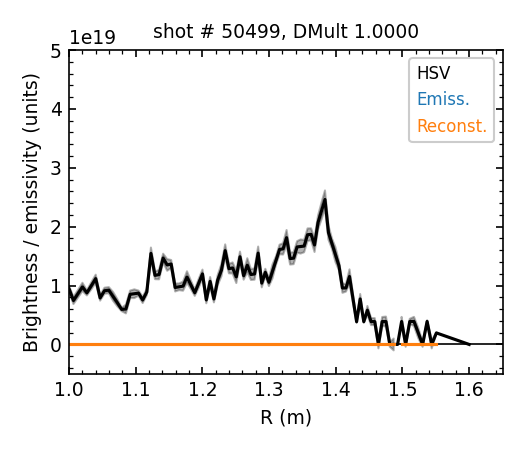

In [85]:
xlim = [1.,1.65]
ylim = [-0.05e20, 0.5e20]

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot(R, data[tind], c='k', label='HSV')
ax.fill_between(
    R, data[tind]-err[tind], 
    data[tind]+err[tind], color='k', alpha=0.3
)

ax.plot(RgridB, Y, c='C0', label='Emiss.')
ax.fill_between(
    RgridB, Y-yErr, Y+yErr, color='C0', alpha=0.3
)

ax.plot(R, backprojection, c='C1', label='Reconst.')

ax.set_xlim(xlim)
ax.plot(xlim, [0.,0.], '-k', lw=0.8, zorder=1)
ax.set_ylim(ylim)
ax.legend(
    fancybox=1, framealpha=1, fontsize=8, 
    handlelength=0, handletextpad=0, labelcolor='linecolor'
)

ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('Brightness / emissivity (units)', fontsize=9)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.minorticks_on()
ax.yaxis.get_offset_text().set_size(9)

ax.set_title(f'shot # {shotn}, DMult {Dmult:.4f}', fontsize=9)

plt.tight_layout()

In [86]:
backprojection

array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0., nan,  0.,  0.,  0.,  0.,  0.,  0

In [87]:
# np.savez(
#     f'/home/sthoma/tokamak_inversion_routines/Testing/TestingAlgorithm/DMult/{shotn}_Dmult_{Dmult:.4f}.npy',
#     R = R, 
#     RgridB = RgridB, 
#     y = Y, 
#     yErr = yErr, 
#     data = data[tind], 
#     err = err[tind], 
#     backprojection = backprojection, 
# )